# Pneumonia Detection from Chest X-rays using DenseNet121

## Objective
Build a deep learning model to classify chest X-ray images into Normal and Pneumonia classes.

## Highlights
- Patient-level splitting to prevent data leakage
- Transfer learning using DenseNet121
- Class imbalance handling
- Model evaluation using AUC, F1-score, Recall

## **Importing libraries**

In [1]:
import torch
import numpy as np
import pandas as pd
from torch import nn
import os,random,cv2
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import DataLoader,Dataset ,WeightedRandomSampler
from torchvision.models import DenseNet121_Weights,densenet121
from sklearn.metrics import (
    classification_report,
    confusion_matrix ,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_curve,
    roc_auc_score)

## **Reading data**

In [2]:
main_path = '/kaggle/input/datasets/tolgadincer/labeled-chest-xray-images/chest_xray'
train_path = os.path.join(main_path,'train')
test_path = os.path.join(main_path,'test')

train_images = []
labels = []

test_images = []
test_labels = []

# for train data
for file_train in os.listdir(train_path):
    fils_path = os.path.join(train_path,file_train)
    
    for images in os.listdir(fils_path):
        img = os.path.join(fils_path,images)
        train_images.append(img)
        
        if file_train == 'PNEUMONIA':
            labels.append(1)
        else : labels.append(0)


# for test data
for file_test in os.listdir(test_path):
    fils_path_test = os.path.join(test_path,file_test)
    
    for images_test in os.listdir(fils_path_test):
        img_test = os.path.join(fils_path_test,images_test)
        test_images.append(img_test)
        if file_test == 'PNEUMONIA':
               test_labels.append(1)
        else : test_labels.append(0)

To check No.of images and labels at train data and test data:

In [3]:
print(f'len images at train data : {len(train_images)} images ')
print(f'len labels at train data : {len(labels)} labels ')
print(f'len images at test data : {len(test_images)} images ')

len images at train data : 5232 images 
len labels at train data : 5232 labels 
len images at test data : 624 images 


We check No.of channles which images have:

In [4]:
img  = cv2.imread(train_images[0])
print(f'shape of images is : {img.shape}')

shape of images is : (1032, 1528, 3)


## **Visualization random samples of images**

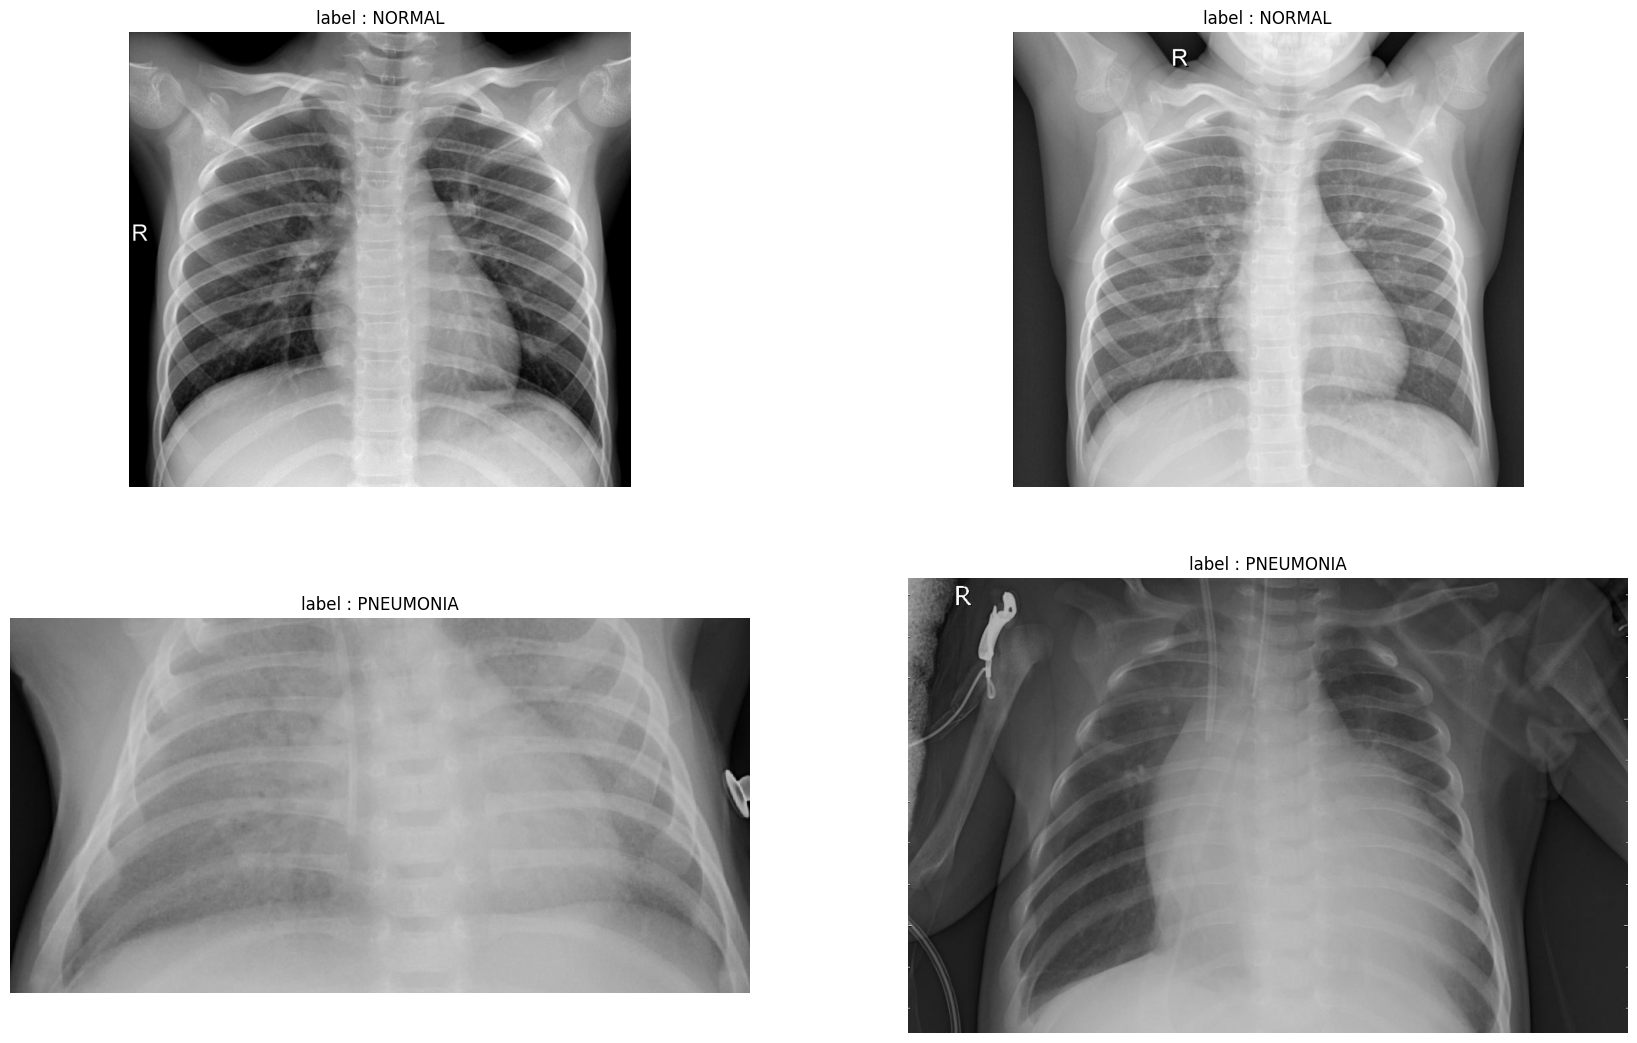

In [5]:
classes = {
    0 :'NORMAL',
    1 :"PNEUMONIA"
}
rand = random.sample(range(len(train_images)),4)
plt.figure(figsize=(21,13))

for i ,idx in enumerate(rand):
    img = cv2.imread(train_images[idx])
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.title(f'label : {classes[labels[idx]]}')
    plt.axis('off')
    plt.imshow(img)

plt.show()

To know if data is palanced or not:

In [6]:
counts = pd.Series(labels).value_counts()
print(counts)

1    3883
0    1349
Name: count, dtype: int64


Visualization by using barplot:

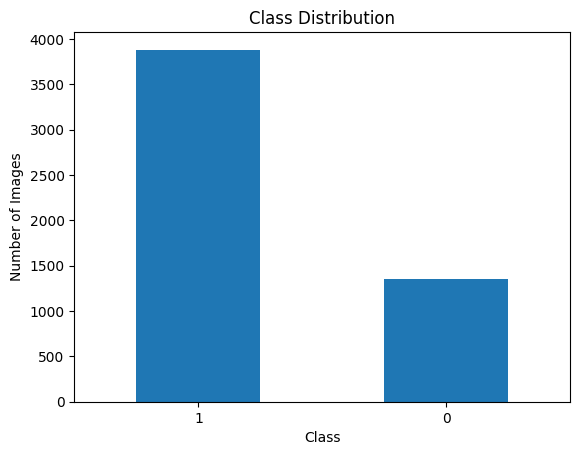

In [7]:
counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

Data is not palanced 

## **Splitting data**

We make Stratified Group Split at patient_id due to if patient has more than one image so if we used normal splitting may images for the same patient split to val data so that make leakage:

In [8]:
def get_patient_id(path):
    filename = os.path.basename(path)

    return filename.split("-")[1]

# Patient ID for evry image
groups = np.array([
    get_patient_id(path)
    for path in train_images
])

X = np.array(train_images)
y = np.array(labels)


# Stratified Group Split
sgkf = StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=4)

train_idx, val_idx = next(sgkf.split(X,y,groups=groups))

# Train
X_train = X[train_idx].tolist()
y_train = y[train_idx].tolist()

# Validation
X_val = X[val_idx].tolist()
y_val = y[val_idx].tolist()

We check if there is found any overlap between train and val data which make data leakage:

In [9]:
train_patients = {
    get_patient_id(x)
    for x in X_train
}

val_patients = {
    get_patient_id(x)
    for x in X_val
}

overlap = train_patients & val_patients

print("Train images:", len(X_train))
print("Validation images:", len(X_val))

print("Train patients:", len(train_patients))
print("Validation patients:", len(val_patients))

print("Patient overlap:", len(overlap))

Train images: 4172
Validation images: 1060
Train patients: 2121
Validation patients: 529
Patient overlap: 0


In [10]:
print(f'No. of images at X_train : {len(X_train)} images')
print(f'No. of labels at y_train : {len(y_train)} labels')
print(f'No. of images at X_val : {len(X_val)} images')
print(f'No. of labels at y_val : {len(y_val)} labesl')

No. of images at X_train : 4172 images
No. of labels at y_train : 4172 labels
No. of images at X_val : 1060 images
No. of labels at y_val : 1060 labesl


## **Custom data**

In [11]:
class X_raydata(Dataset):
    
    def __init__(self,images,labels,transforms=None):
        self.images = images
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
       return len(self.images)

    def __getitem__(self,idx):
        image = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]
        
        if self.transforms:
            image = self.transforms(image)

            return image , label

## **Transforms**

In [12]:
# train transform
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    
    transforms.RandomAffine(
        degrees =10,
        translate = (0.05,0.05),
        scale = (0.95,1.05)),

    
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485,0.456,0.406],
        std = [0.229,0.224,0.225]
    )
])

# val transform
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485,0.456,0.406],
        std = [0.229,0.224,0.225]
    )
])

## **Building dataset**

In [13]:
# train dataset
train_dataset = X_raydata(
    X_train,
    y_train,
    transforms = train_transform
)
# val dataset
val_dataset = X_raydata(
    X_val,
    y_val,
    transforms = val_transform
)

To deal with non palanced data by using **WeightedRandomSampler** :

In [14]:
labels_tensor = torch.tensor(train_dataset.labels)

class_counts = torch.bincount(labels_tensor)

class_weights = 1.0 / class_counts.float()

sample_weights = class_weights[labels_tensor]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_dataset),
    replacement=True
)

## **DataLoader**

In [15]:
BZ = 30 # batch size

# train loader
train_loader = DataLoader(
    train_dataset,
    batch_size = BZ,
    sampler = sampler
)

# val loader
val_loader = DataLoader(
    val_dataset,
    batch_size = BZ,
    shuffle = False
)

## **Modeling**

## **Final Model Selection**

We use **Dense121_Model**

In [16]:
Dens121_model = densenet121(weights = DenseNet121_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 236MB/s]


### **HyperParameters for model**

In [17]:
# we freez all layers of model
for param in Dens121_model.parameters():
    param.requires_grad = False

# change last layer according to No. of calssification
in_features = Dens121_model.classifier.in_features
Dens121_model.classifier = nn.Sequential(
    nn.Linear(in_features,2)
)

# we not freez fc layer
for param in Dens121_model.classifier.parameters():
    param.requires_grad = True

# we not freez last layer of model
for param in Dens121_model.features.denseblock4.denselayer16.parameters():
    param.requires_grad = True


# Hyperparmeters for Model
lr = 1e-4
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad,Dens121_model.parameters()),lr=lr)
# learning rate scadular
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = 'min',
    patience=2,
    factor=0.5
)

# We move model to device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
Dens121_model = Dens121_model.to(device)
print(f'your device is :{device}')

your device is :cuda


## **Training and Vlaidation loop**

In [18]:
epochs = 70

patience = 3
counter = 0
best_val_loss = float("inf")

# Lists for plotting
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

val_precisions = []
val_recalls = []
val_f1s = []

# Store probabilities for threshold tuning
all_val_probs = []
all_val_labels = []


for epoch in range(epochs):

    # Training
    Dens121_model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = Dens121_model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total


    # Validation
    Dens121_model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    # Probabilities and labels for threshold tuning
    epoch_val_probs = []
    epoch_val_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = Dens121_model(images)

            loss = loss_fn(outputs, labels)

            val_loss += loss.item()

            # Normal prediction using argmax
            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            # Probability of PNEUMONIA
            probs = torch.softmax(outputs, dim=1)

            pneumonia_probs = probs[:, 1]

            epoch_val_probs.extend(
                pneumonia_probs.cpu().numpy()
            )

            epoch_val_labels.extend(
                labels.cpu().numpy()
            )


    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total


    # Metrics at threshold = 0.5
    val_preds = [
        1 if prob >= 0.5 else 0
        for prob in epoch_val_probs
    ]

    val_precision = precision_score(epoch_val_labels,val_preds,zero_division=0)
    val_recall = recall_score(epoch_val_labels,val_preds,zero_division=0)
    val_f1 = f1_score(epoch_val_labels,val_preds,zero_division=0)


    #  Metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    val_precisions.append(val_precision)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)


    # Learning Rate Scheduler
    scheduler.step(val_loss)

    # Results
    print(f"Epoch [{epoch+1}/{epochs}]")

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Train Accuracy  : {train_acc:.2f}%")

    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Acc  : {val_acc:.2f}%")

    print(f"Validation Precision : {val_precision:.4f}")
    print(f"Validation Recall    : {val_recall:.4f}")
    print(f"Validation F1        : {val_f1:.4f}")

    print("-" * 50)


    # Early Stopping
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        counter = 0

        torch.save(
            Dens121_model.state_dict(),
            "best_Dens121_model.pth"
        )

        print("Best model saved.\n")

    else:

        counter += 1

        print(
            f"EarlyStopping Counter: "
            f"{counter}/{patience}\n"
        )

        if counter >= patience:

            print("Early Stopping...")
            break

Epoch [1/70]
Train Loss      : 0.4408
Train Accuracy  : 84.06%
Validation Loss : 0.3117
Validation Acc  : 90.85%
Validation Precision : 0.9891
Validation Recall    : 0.8907
Validation F1        : 0.9373
--------------------------------------------------
Best model saved.

Epoch [2/70]
Train Loss      : 0.2210
Train Accuracy  : 94.20%
Validation Loss : 0.2427
Validation Acc  : 91.79%
Validation Precision : 0.9932
Validation Recall    : 0.8993
Validation F1        : 0.9439
--------------------------------------------------
Best model saved.

Epoch [3/70]
Train Loss      : 0.1496
Train Accuracy  : 95.93%
Validation Loss : 0.1780
Validation Acc  : 93.87%
Validation Precision : 0.9947
Validation Recall    : 0.9251
Validation F1        : 0.9586
--------------------------------------------------
Best model saved.

Epoch [4/70]
Train Loss      : 0.1259
Train Accuracy  : 96.31%
Validation Loss : 0.1382
Validation Acc  : 95.09%
Validation Precision : 0.9922
Validation Recall    : 0.9435
Validati

### **Final Model performance**

#### **To visualization train and validation loss**

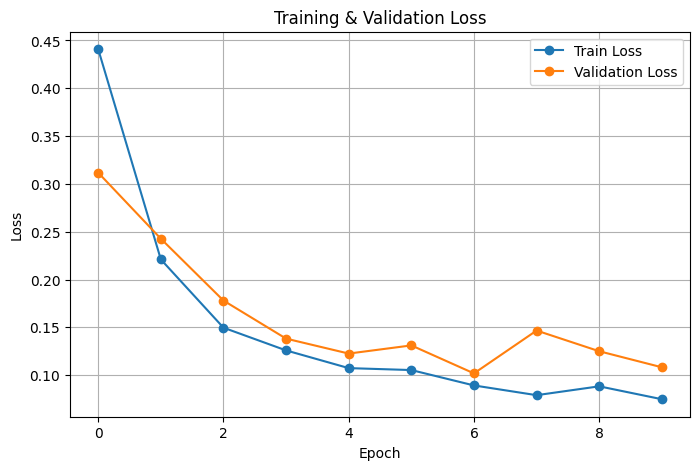

In [19]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o', label='Train Loss')
plt.plot(val_losses, marker='o', label='Validation Loss')
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

#### **Confusion matrix**

In [20]:
Dens121_model.eval()

y_trues = []
y_preds = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = Dens121_model(images)

        preds = torch.argmax(outputs, dim=1)

        y_trues.extend(labels.cpu().numpy())
        y_preds.extend(preds.cpu().numpy())

In [21]:
print(classification_report(y_trues,y_preds))

print(confusion_matrix(y_trues, y_preds))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92       246
           1       1.00      0.95      0.97       814

    accuracy                           0.96      1060
   macro avg       0.93      0.97      0.95      1060
weighted avg       0.97      0.96      0.96      1060

[[243   3]
 [ 38 776]]


[[243   3]
 [ 38 776]]


<Figure size 1500x800 with 0 Axes>

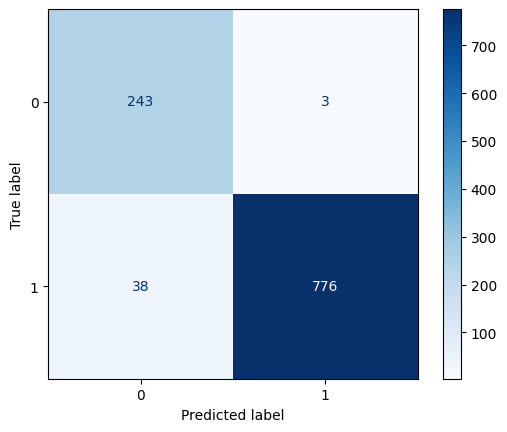

In [22]:
# calculate Confusion Matrix
cm = confusion_matrix(y_trues, y_preds)
print(cm)
#  Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

plt.figure(figsize=(15,8))
disp.plot(cmap="Blues", xticks_rotation=0)
plt.show()

In [23]:
# To load Best Model
Dens121_model.load_state_dict(torch.load("best_Dens121_model.pth"))
Dens121_model = Dens121_model.to(device)

### **Test data**

### **Visualization random sample of test imags**

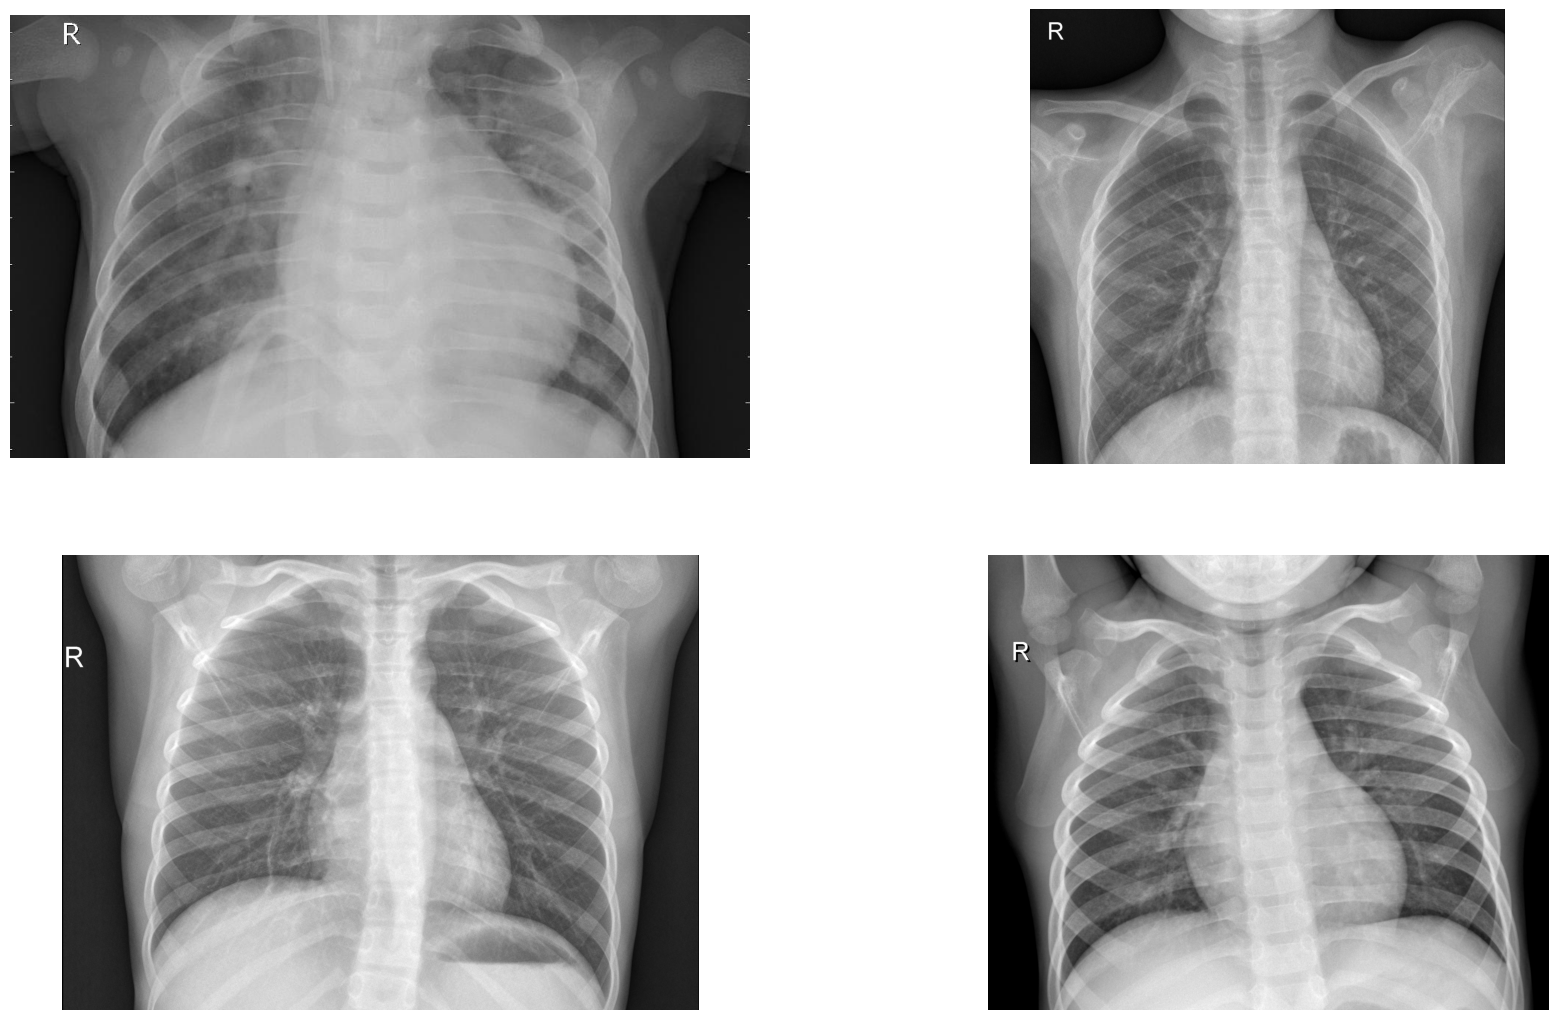

In [24]:
rand = random.sample(range(len(test_images)),4)
plt.figure(figsize=(21,13))

for i ,idx in enumerate(rand):
    img = cv2.imread(test_images[idx])
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.axis('off')
    plt.imshow(img)

plt.show()

**Transforms test data**

In [25]:
# test transform
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485,0.456,0.406],
        std = [0.229,0.224,0.225]
    )
])

**Building dataset to test data**

In [26]:
test_dataset = X_raydata(
    test_images,
    test_labels,
    transforms = test_transform
)

**DataLoader to test data**

In [27]:
test_loader = DataLoader(
    test_dataset,
    batch_size = BZ,
    shuffle = False
)

## **Prediction**

In [28]:
all_test_labels = []
all_test_preds = []
all_test_probs = []

Dens121_model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = Dens121_model(images)

        # Probability of each class
        probs = torch.softmax(outputs, dim=1)

        # Probability of PNEUMONIA (class 1)
        pneumonia_probs = probs[:, 1]

        # Prediction
        _, preds = torch.max(outputs, 1)

        all_test_labels.extend(labels.cpu().numpy())
        all_test_preds.extend(preds.cpu().numpy())
        all_test_probs.extend(pneumonia_probs.cpu().numpy())

### **Classification Report for test data**

In [29]:
print(
    classification_report(
        all_test_labels,
        all_test_preds,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.98      0.90      0.94       234
   PNEUMONIA       0.94      0.99      0.96       390

    accuracy                           0.95       624
   macro avg       0.96      0.94      0.95       624
weighted avg       0.95      0.95      0.95       624



### **Confusion Matrix for test data**

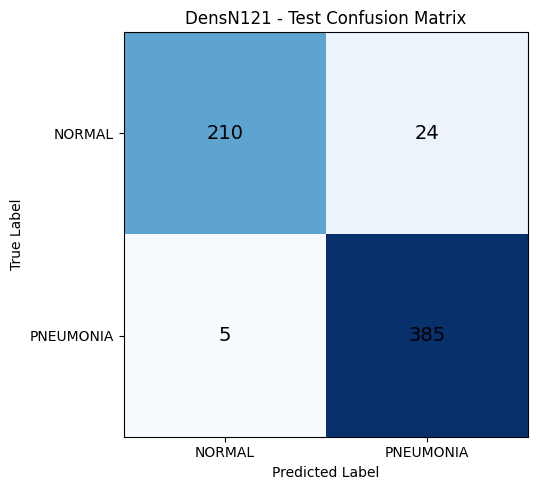

In [30]:
cm = confusion_matrix(all_test_labels, all_test_preds)

plt.figure(figsize=(6, 5))

plt.imshow(cm,cmap="Blues")

plt.title("DensN121 - Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["NORMAL", "PNEUMONIA"])
plt.yticks([0, 1], ["NORMAL", "PNEUMONIA"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.tight_layout()
plt.show()

### **Classification Metrics (Accuracy , Precision,Recall,F1_score)**

Accuracy  : 0.9535
Precision : 0.9546
Recall    : 0.9535
F1-score  : 0.9531
AUC       : 0.9885


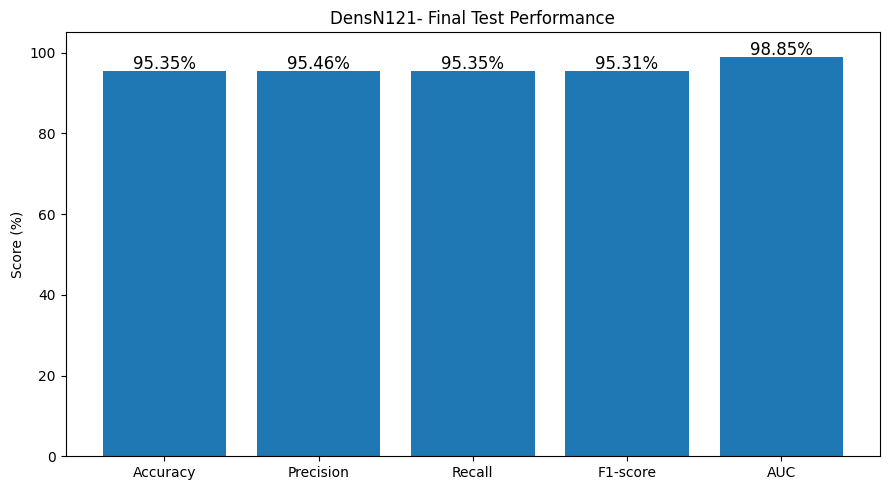

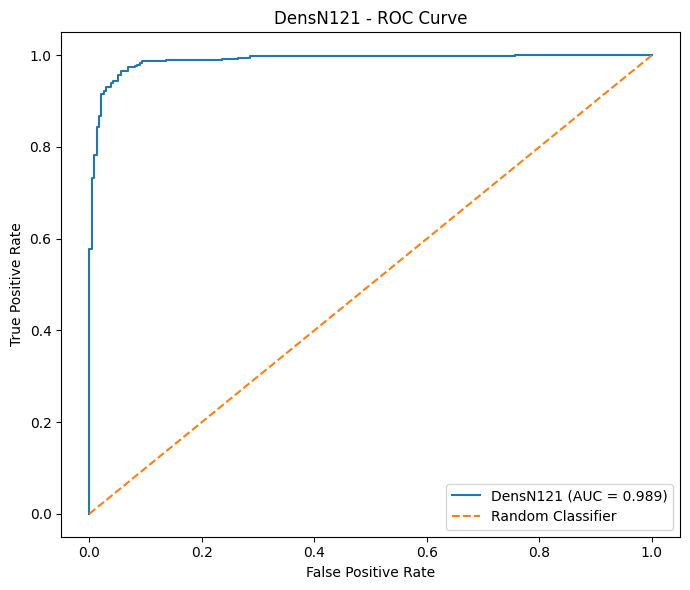

In [31]:
# Classification Metrics
accuracy = accuracy_score(all_test_labels,all_test_preds)

precision = precision_score(all_test_labels,all_test_preds,average="weighted")

recall = recall_score(all_test_labels,all_test_preds,average="weighted")

f1 = f1_score(all_test_labels,all_test_preds,average="weighted")

# ROC Curve & AUC

fpr, tpr, thresholds = roc_curve(all_test_labels,all_test_probs)

auc_score = roc_auc_score(all_test_labels,all_test_probs)

#  Results
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"AUC       : {auc_score:.4f}")


# Metrics Bar Chart
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "AUC"
]

values = [
    accuracy * 100,
    precision * 100,
    recall * 100,
    f1 * 100,
    auc_score * 100
]


plt.figure(figsize=(9, 5))

bars = plt.bar(metrics, values)

for bar, value in zip(bars, values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        fontsize=12
    )

plt.title("DensN121- Final Test Performance")
plt.ylabel("Score (%)")
plt.ylim(0, 105)
plt.tight_layout()
plt.show()


# ROC Curve
plt.figure(figsize=(7, 6))

plt.plot(fpr,tpr,label=f"DensN121 (AUC = {auc_score:.3f})")
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DensN121 - ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

### **Visualization True images VS Predicted images**

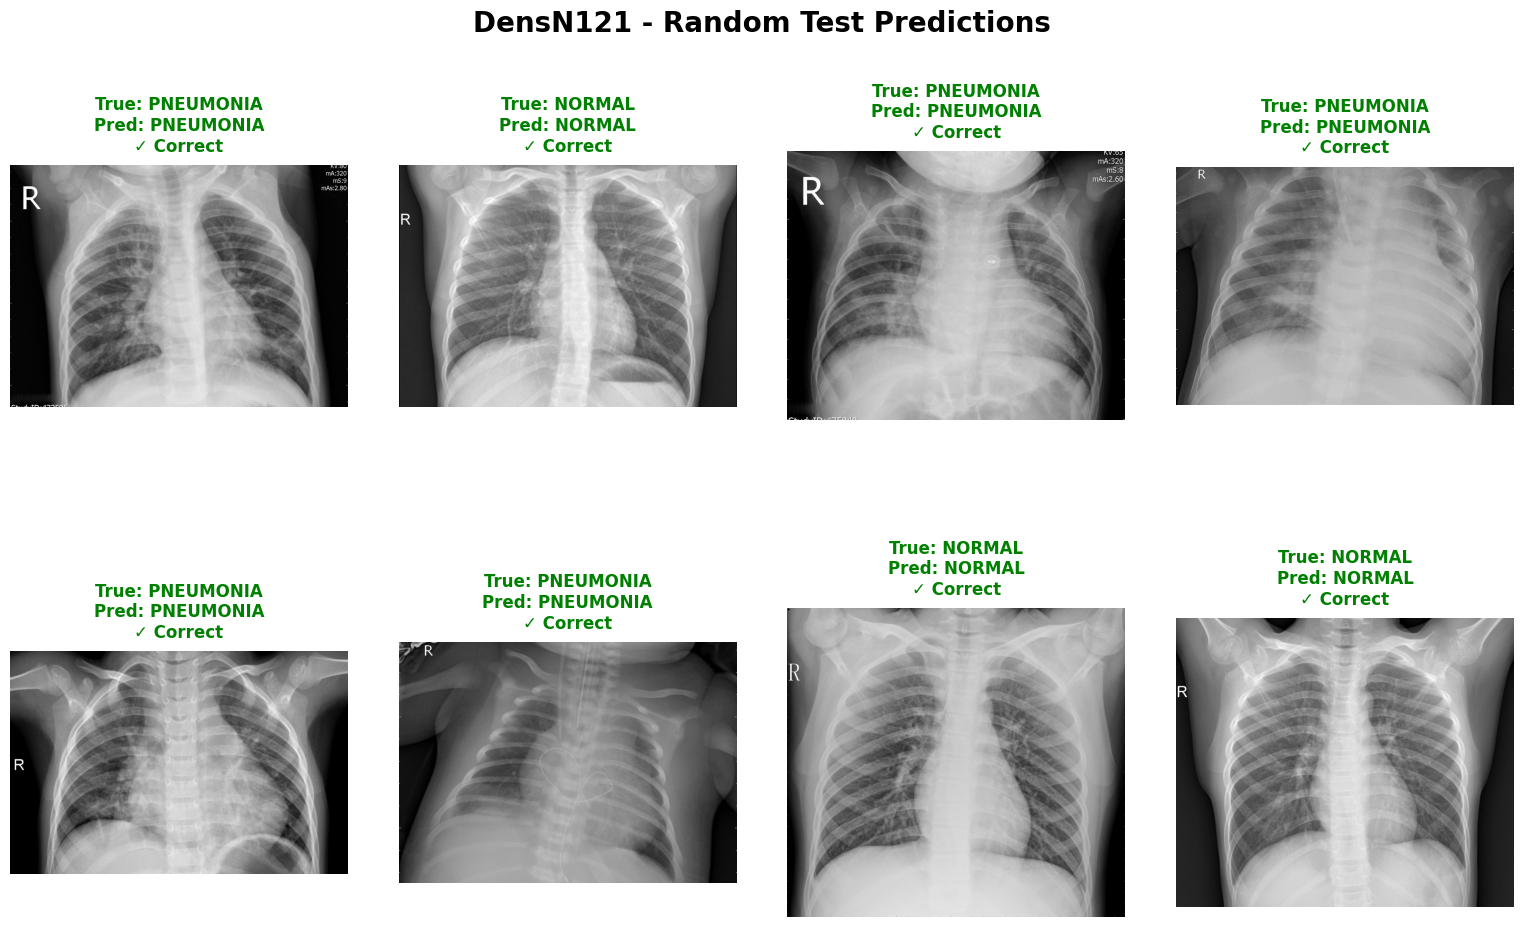

In [32]:
# Number of random images
num_images = 8

# Random indices
random_indices = random.sample(range(len(test_images)), num_images)

class_names = ["NORMAL", "PNEUMONIA"]

# Create figure
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
fig.suptitle(
    "DensN121 - Random Test Predictions",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

# Flatten axes
axes = axes.flatten()

for i, idx in enumerate(random_indices):

    # Read image
    img = cv2.imread(test_images[idx])

    if img is None:
        axes[i].axis("off")
        continue

    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # True and predicted labels
    true_label = all_test_labels[idx]
    pred_label = all_test_preds[idx]

    true_name = class_names[true_label]
    pred_name = class_names[pred_label]

    # Correct / Wrong
    is_correct = true_label == pred_label

    if is_correct:
        title_color = "green"
        status = "✓ Correct"
    else:
        title_color = "red"
        status = "✗ Wrong"

    # Plot image
    axes[i].imshow(img)
    axes[i].set_title(
        f"True: {true_name}\n"
        f"Pred: {pred_name}\n"
        f"{status}",
        fontsize=12,
        fontweight="bold",
        color=title_color,
        pad=10
    )

    axes[i].axis("off")

# Hide unused subplots
for j in range(len(random_indices), len(axes)):
    axes[j].axis("off")

# Improve spacing
plt.subplots_adjust(
    top=0.88,
    bottom=0.05,
    left=0.03,
    right=0.97,
    hspace=0.35,
    wspace=0.15
)

plt.show()